# Task 2.1 — Dataset Selection and Setup (5 marks)

**Paper**: *Robust Point Set Registration Using Gaussian Mixture Models* — Bing Jian and Baba C. Vemuri, IEEE TPAMI, 2011.

---

## Dataset Choice and Justification

We use a **synthetic 2D point set** generated from a closed curve that resembles a deformed circle (circle with sinusoidal radial perturbation). The model consists of approximately 150 points. The scene is created by applying a known non-rigid deformation to the model (local stretching and bending), adding Gaussian noise ($\sigma = 0.02$), and inserting approximately 20 random outlier points within the bounding box.

This dataset is a **reasonable testbed** for the GMM registration method because: (1) it is a 2D non-rigid point set registration problem, which is exactly the problem class the paper addresses (Section 6, fish experiments); (2) the known ground-truth deformation allows us to quantitatively evaluate registration accuracy using MSE; (3) the inclusion of noise and outliers tests the robustness claims made by the paper.

**Limitations** compared to the paper's datasets: our toy data is smaller (150 vs. 91-98 points in the fish dataset) and has a simpler shape. The paper also tests on 3D range scans, face data, and motion capture data, which we do not attempt here. Our deformation is synthetic and controlled, whereas the paper's deformations arise from real physical processes.

---

## Preprocessing Steps

1. **Normalisation**: Both model and scene are centred to zero mean and scaled to unit variance, following the `normalize` flag in the author's implementation.
2. **Random seed**: Set to `42` for reproducibility.

In [1]:
# ============================================================
# Hyperparameters and Random Seed
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import os

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N_POINTS = 150       # Number of model points
NOISE_STD = 0.02     # Gaussian noise standard deviation
N_OUTLIERS = 20      # Number of outlier points

# Ensure output directories exist
os.makedirs('data', exist_ok=True)
os.makedirs('results', exist_ok=True)

### Generating the Model Point Set

We sample 150 points from a 2D closed curve defined by:
$r(\theta) = 1 + 0.3 \sin(3\theta)$
in polar coordinates, which creates a flower-like shape.

In [2]:
# ============================================================
# Generate Model Point Set (flower-like closed curve)
# ============================================================
theta = np.linspace(0, 2 * np.pi, N_POINTS, endpoint=False)
r = 1.0 + 0.3 * np.sin(3 * theta)
model_x = r * np.cos(theta)
model_y = r * np.sin(theta)
model = np.column_stack([model_x, model_y])

print(f"Model shape: {model.shape}")
print(f"Model x range: [{model_x.min():.3f}, {model_x.max():.3f}]")
print(f"Model y range: [{model_y.min():.3f}, {model_y.max():.3f}]")

Model shape: (150, 2)
Model x range: [-1.184, 1.184]
Model y range: [-1.299, 0.884]


### Generating the Scene Point Set

The scene is created by:
1. Applying a non-rigid deformation: local stretching in $x$ and bending via a sinusoidal displacement in $y$.
2. Adding Gaussian noise with $\sigma = 0.02$ to simulate measurement uncertainty.
3. Adding 20 uniformly random outlier points within the bounding box.

In [3]:
# ============================================================
# Generate Scene Point Set (deformed model + noise + outliers)
# ============================================================

# Non-rigid deformation: stretch x slightly, bend y
def nonrigid_deformation(pts):
    """Apply a synthetic non-rigid deformation to a 2D point set."""
    deformed = pts.copy()
    deformed[:, 0] = pts[:, 0] * 1.1 + 0.15 * np.sin(2 * np.pi * pts[:, 1] / 2.0)
    deformed[:, 1] = pts[:, 1] * 0.95 + 0.1 * np.cos(2 * np.pi * pts[:, 0] / 2.0)
    return deformed

# Apply deformation
scene_clean = nonrigid_deformation(model)

# Add Gaussian noise
noise = np.random.randn(N_POINTS, 2) * NOISE_STD
scene_noisy = scene_clean + noise

# Add outliers uniformly distributed within the bounding box
bbox_min = scene_noisy.min(axis=0) - 0.3
bbox_max = scene_noisy.max(axis=0) + 0.3
outliers = np.random.uniform(bbox_min, bbox_max, size=(N_OUTLIERS, 2))

# Combined scene: noisy deformed points + outliers
scene = np.vstack([scene_noisy, outliers])

print(f"Scene shape (with outliers): {scene.shape}")
print(f"Clean scene shape: {scene_clean.shape}")

Scene shape (with outliers): (170, 2)
Clean scene shape: (150, 2)


### Save Data and Visualise

We save the model, scene, and clean scene (ground truth) as text files for use in subsequent tasks.

In [4]:
# ============================================================
# Save datasets
# ============================================================
np.savetxt('data/model.txt', model, fmt='%.6f')
np.savetxt('data/scene.txt', scene, fmt='%.6f')
np.savetxt('data/scene_clean.txt', scene_clean, fmt='%.6f')

print("Saved: data/model.txt, data/scene.txt, data/scene_clean.txt")

Saved: data/model.txt, data/scene.txt, data/scene_clean.txt


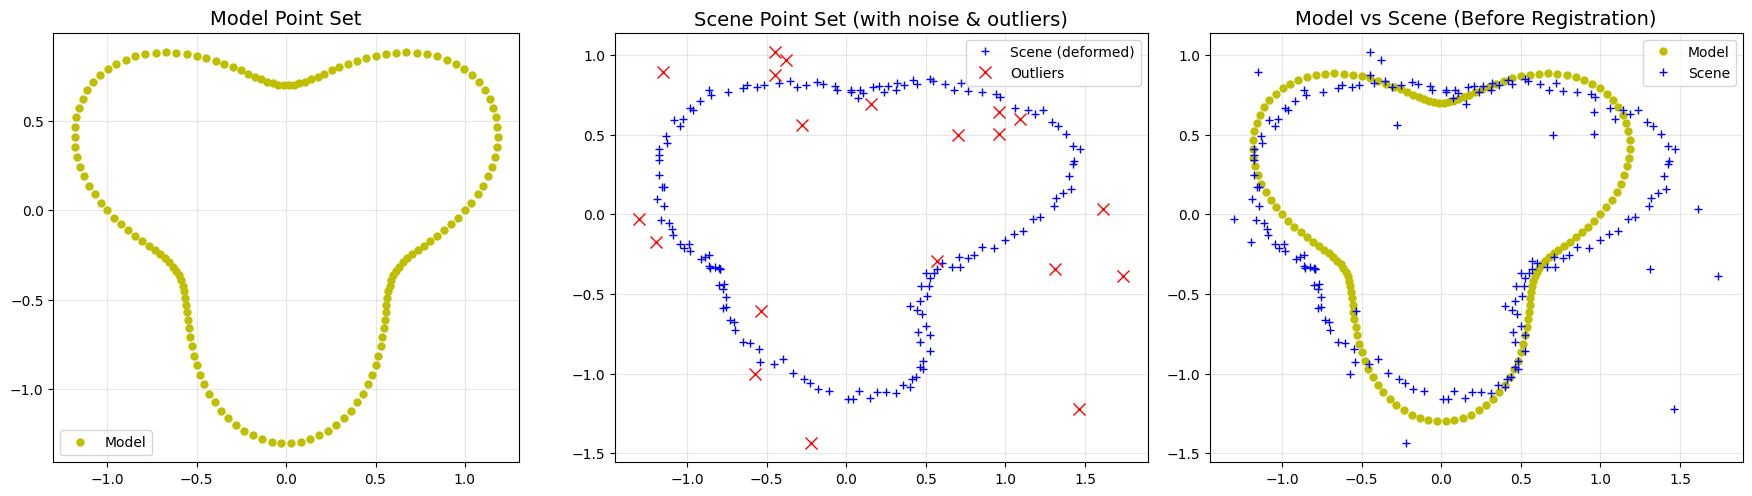

Saved: results/dataset_overview.png


In [5]:
# ============================================================
# Visualise model and scene
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Model only
axes[0].plot(model[:, 0], model[:, 1], 'yo', markersize=5, label='Model')
axes[0].set_title('Model Point Set', fontsize=14)
axes[0].set_aspect('equal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Scene only
axes[1].plot(scene_noisy[:, 0], scene_noisy[:, 1], 'b+', markersize=6, label='Scene (deformed)')
axes[1].plot(outliers[:, 0], outliers[:, 1], 'rx', markersize=8, label='Outliers')
axes[1].set_title('Scene Point Set (with noise & outliers)', fontsize=14)
axes[1].set_aspect('equal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Overlay
axes[2].plot(model[:, 0], model[:, 1], 'yo', markersize=5, label='Model')
axes[2].plot(scene[:, 0], scene[:, 1], 'b+', markersize=6, label='Scene')
axes[2].set_title('Model vs Scene (Before Registration)', fontsize=14)
axes[2].set_aspect('equal')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/dataset_overview.png")